Задание 1 (4 балла)
1. Скачать данные по ссылке https://www.kaggle.com/datasets/nikhil7280/weather-type-classification/data
2. Построить модели классификации данных (y – Weather Type) используя от 3-х различных алгоритмов (например, k-NN, SVM и т.д.);
3. Самостоятельно изучить другие метрики качества для моделей (Precision, Recall, F1-мера и тд);
4. Сравнить качество полученных моделей.

Задание * (4 балла)
1. Для данных из примера (https://www.kaggle.com/datasets/tourist55/clothessizeprediction/data) улучшить точность модели классификации до 0,7 и выше. 

Первые 5 строк датасета о погоде:
   Temperature  Humidity  Wind Speed  Precipitation (%)    Cloud Cover  \
0         14.0        73         9.5               82.0  partly cloudy   
1         39.0        96         8.5               71.0  partly cloudy   
2         30.0        64         7.0               16.0          clear   
3         38.0        83         1.5               82.0          clear   
4         27.0        74        17.0               66.0       overcast   

   Atmospheric Pressure  UV Index  Season  Visibility (km)  Location  \
0               1010.82         2  Winter              3.5    inland   
1               1011.43         7  Spring             10.0    inland   
2               1018.72         5  Spring              5.5  mountain   
3               1026.25         7  Spring              1.0   coastal   
4                990.67         1  Winter              2.5  mountain   

  Weather Type  
0        Rainy  
1       Cloudy  
2        Sunny  
3        Sunny  
4  

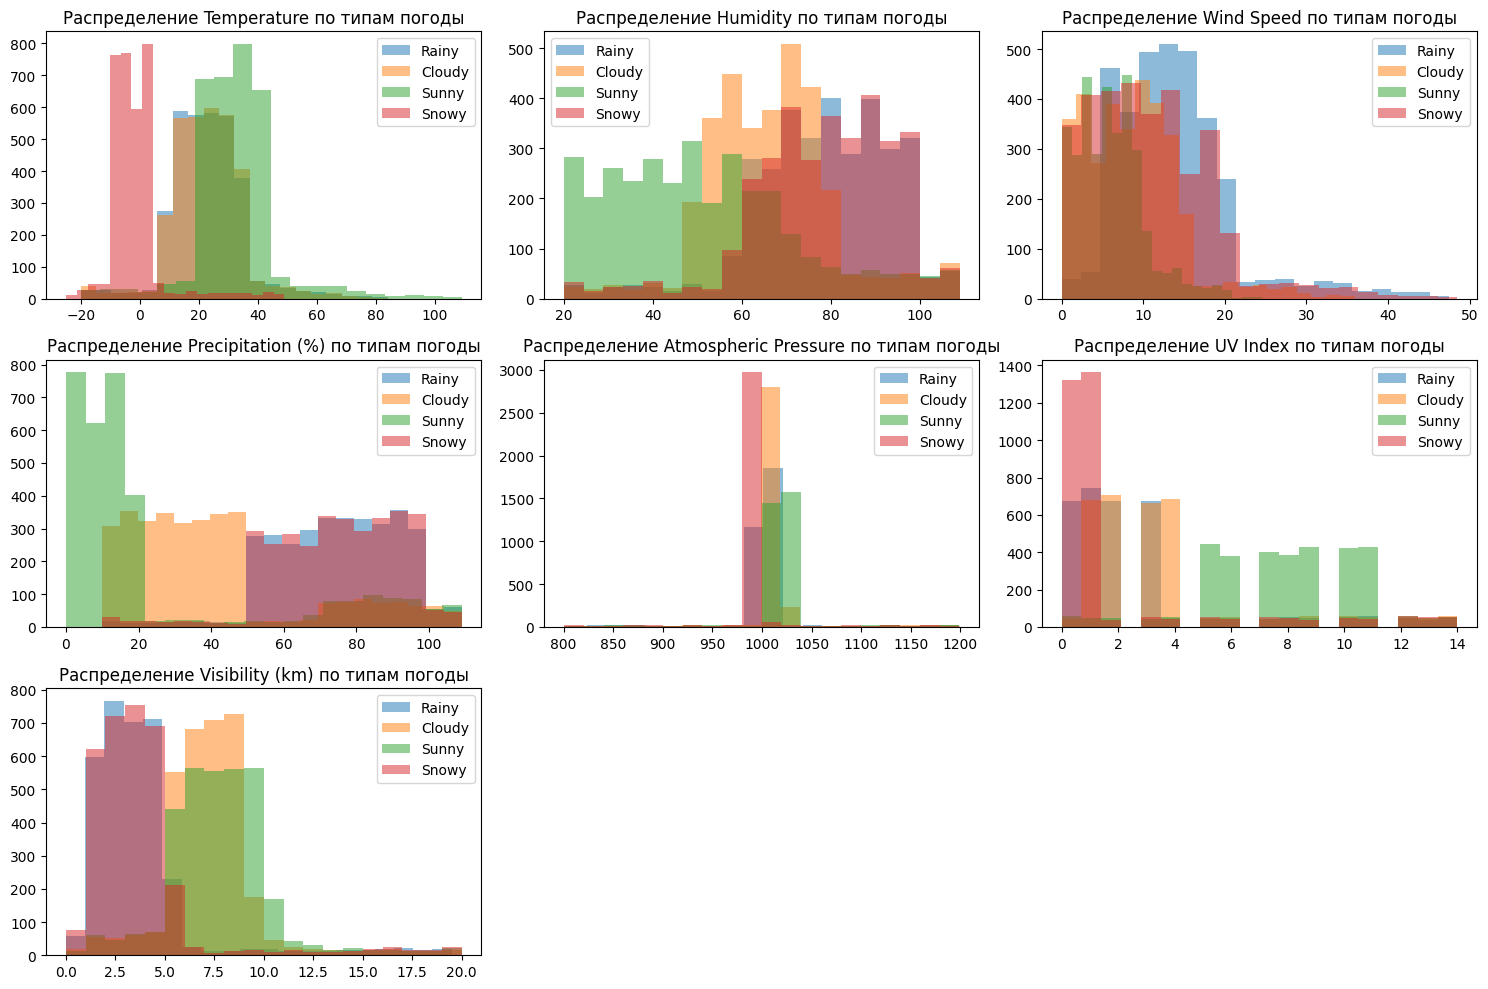


Размер обучающей выборки: (10560, 15)
Размер тестовой выборки: (2640, 15)

k-NN:
  Точность: 0.8932
  Precision: 0.8962
  Recall: 0.8932
  F1-Score: 0.8939
  CV Score: 0.8920 (+/- 0.0055)
              precision    recall  f1-score   support

      Cloudy       0.83      0.89      0.86       660
       Rainy       0.86      0.89      0.87       660
       Snowy       0.94      0.91      0.92       660
       Sunny       0.95      0.88      0.92       660

    accuracy                           0.89      2640
   macro avg       0.90      0.89      0.89      2640
weighted avg       0.90      0.89      0.89      2640


SVM:
  Точность: 0.9072
  Precision: 0.9096
  Recall: 0.9072
  F1-Score: 0.9077
  CV Score: 0.9098 (+/- 0.0058)
              precision    recall  f1-score   support

      Cloudy       0.84      0.91      0.88       660
       Rainy       0.90      0.92      0.91       660
       Snowy       0.95      0.91      0.93       660
       Sunny       0.95      0.89      0.92   

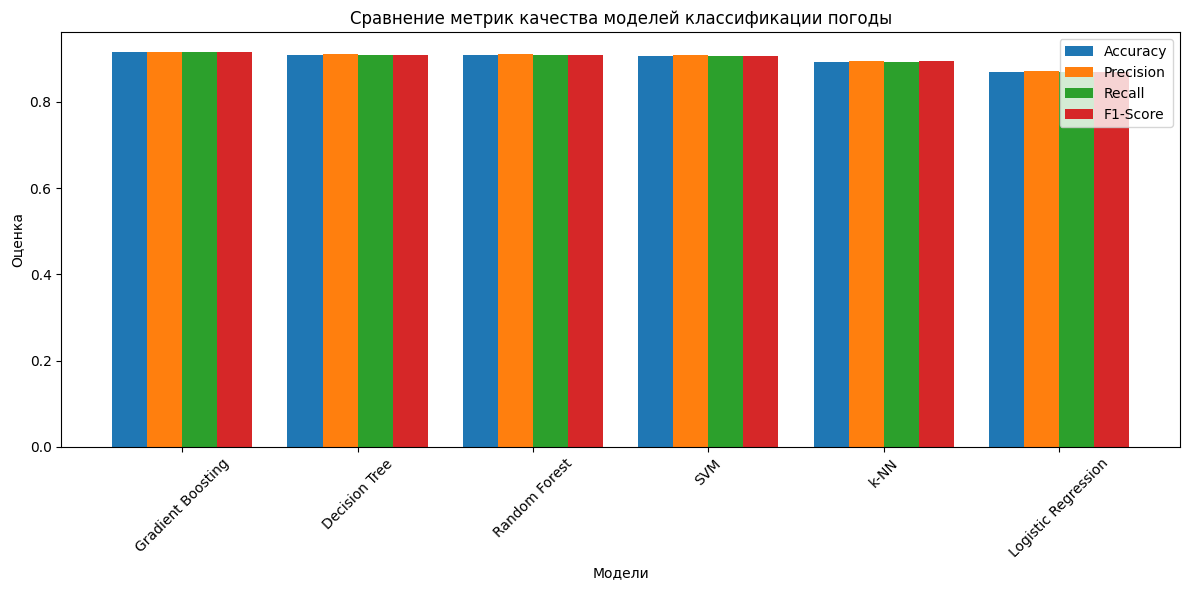

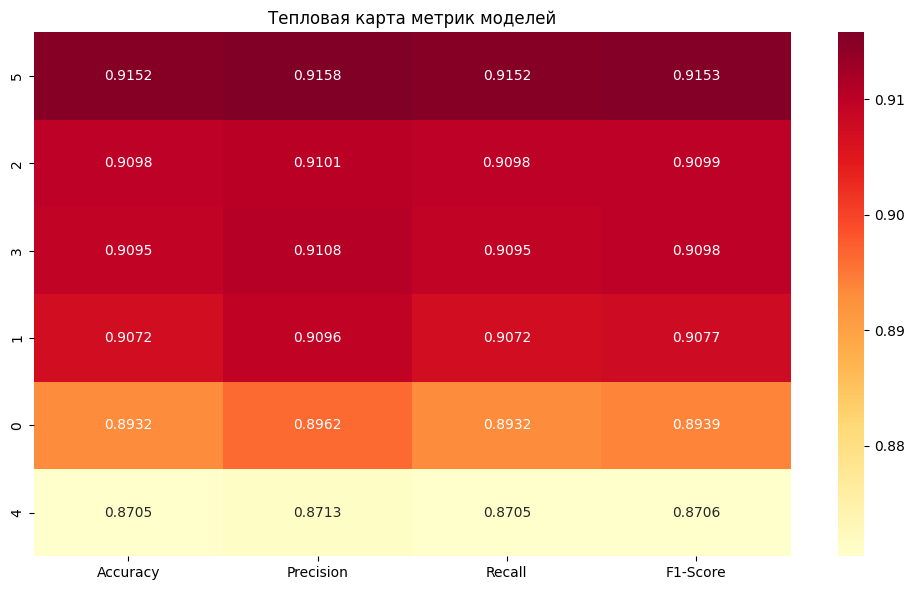

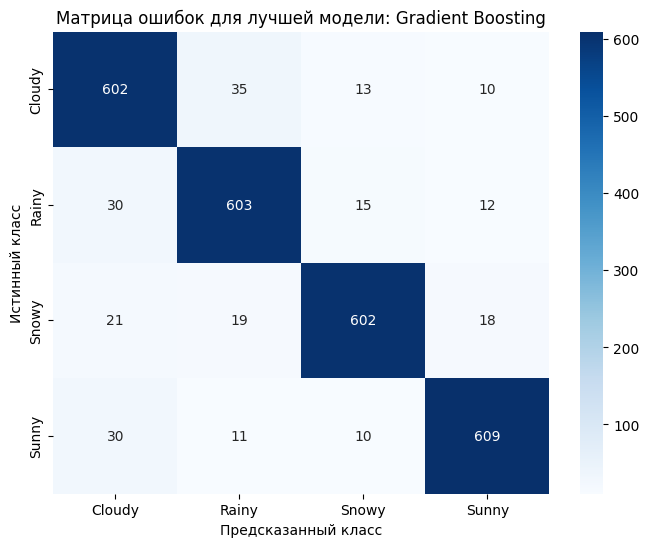

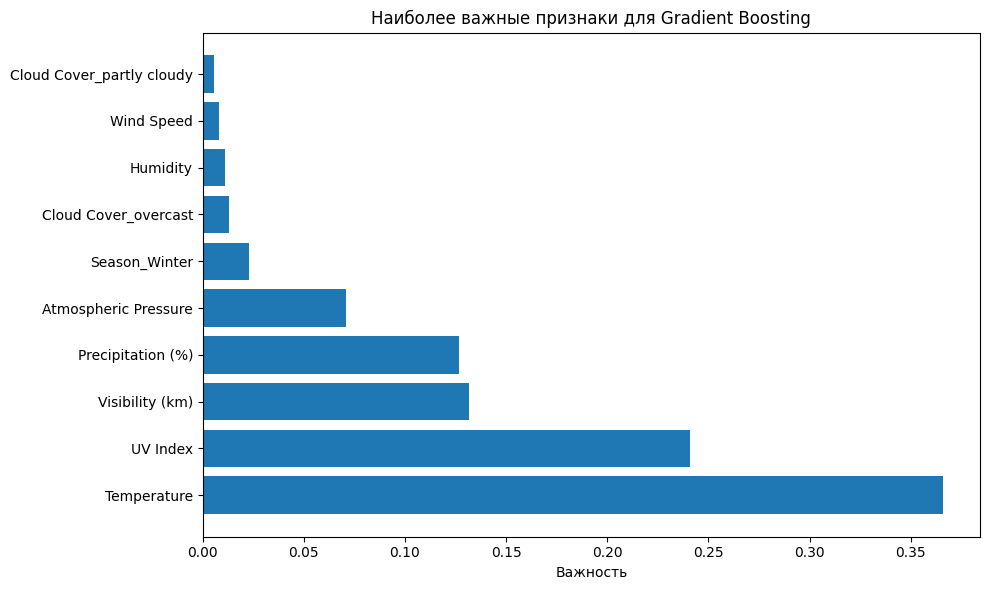

1. Лучшая модель: Gradient Boosting
2. Достигнутая точность: 0.9152
3. F1-мера: 0.9153


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

df_weather = pd.read_csv('weather_classification_data.csv')
print("Первые 5 строк датасета о погоде:")
print(df_weather.head())
print("\nИнформация о датасете:")
print(df_weather.info())
print("\nПропуски в данных:")
print(df_weather.isnull().sum())
print("\nОписательная статистика:")
print(df_weather.describe())

categorical_cols = df_weather.select_dtypes(include=['object']).columns
print(f"\nКатегориальные признаки: {list(categorical_cols)}")

df_weather_encoded = pd.get_dummies(df_weather, columns=['Cloud Cover', 'Season', 'Location'], drop_first=True)

label_encoder = LabelEncoder()
df_weather_encoded['Weather Type'] = label_encoder.fit_transform(df_weather['Weather Type'])
print(f"\nКлассы погоды: {dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))}")

plt.figure(figsize=(15, 10))
for i, col in enumerate(['Temperature', 'Humidity', 'Wind Speed', 'Precipitation (%)', 
                         'Atmospheric Pressure', 'UV Index', 'Visibility (km)']):
    plt.subplot(3, 3, i+1)
    for weather_type in df_weather['Weather Type'].unique():
        subset = df_weather[df_weather['Weather Type'] == weather_type]
        plt.hist(subset[col], alpha=0.5, label=weather_type, bins=20)
    plt.title(f'Распределение {col} по типам погоды')
    plt.legend()
plt.tight_layout()
plt.show()

X = df_weather_encoded.drop('Weather Type', axis=1)
y = df_weather_encoded['Weather Type']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"\nРазмер обучающей выборки: {X_train.shape}")
print(f"Размер тестовой выборки: {X_test.shape}")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

models = {
    'k-NN': KNeighborsClassifier(),
    'SVM': SVC(random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42)
}

results = []
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')
    
    cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='accuracy')
    
    results.append({
        'Model': name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'CV Mean': cv_scores.mean(),
        'CV Std': cv_scores.std()
    })
    
    print(f"\n{name}:")
    print(f"  Точность: {accuracy:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall: {recall:.4f}")
    print(f"  F1-Score: {f1:.4f}")
    print(f"  CV Score: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")
    print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

results_df = pd.DataFrame(results)
results_df = results_df.sort_values('F1-Score', ascending=False)
print("\nСравнение моделей:")
print(results_df.to_string())

plt.figure(figsize=(12, 6))
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
x = np.arange(len(results_df['Model']))
width = 0.2

for i, metric in enumerate(metrics):
    plt.bar(x + i*width, results_df[metric], width, label=metric)

plt.xlabel('Модели')
plt.ylabel('Оценка')
plt.title('Сравнение метрик качества моделей классификации погоды')
plt.xticks(x + width*1.5, results_df['Model'], rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
sns.heatmap(results_df[['Accuracy', 'Precision', 'Recall', 'F1-Score']], 
            annot=True, cmap='YlOrRd', cbar=True, fmt='.4f')
plt.title('Тепловая карта метрик моделей')
plt.tight_layout()
plt.show()

best_model_name = results_df.iloc[0]['Model']
best_model = models[best_model_name]
best_model.fit(X_train_scaled, y_train)
y_pred_best = best_model.predict(X_test_scaled)

cm = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=label_encoder.classes_, 
            yticklabels=label_encoder.classes_)
plt.title(f'Матрица ошибок для лучшей модели: {best_model_name}')
plt.ylabel('Истинный класс')
plt.xlabel('Предсказанный класс')
plt.show()

feature_importance = None
if hasattr(best_model, 'feature_importances_'):
    feature_importance = pd.DataFrame({
        'feature': X.columns,
        'importance': best_model.feature_importances_
    }).sort_values('importance', ascending=False)
    plt.figure(figsize=(10, 6))
    plt.barh(feature_importance['feature'][:10], feature_importance['importance'][:10])
    plt.xlabel('Важность')
    plt.title(f'Наиболее важные признаки для {best_model_name}')
    plt.tight_layout()
    plt.show()

print("1. Лучшая модель:", best_model_name)
print(f"2. Достигнутая точность: {results_df.iloc[0]['Accuracy']:.4f}")
print(f"3. F1-мера: {results_df.iloc[0]['F1-Score']:.4f}")